# RUNOFF storm episodes: a guided tour of the dataset

This notebook teaches the dataset by using it. Every step has a short note on what the code does
and why, then the code, then the result.

**What the dataset is**

- Flash flood storm episodes over the lower 48 states, water years 2021 to 2025
- For each episode: the reports that make it up, the watersheds it touched, the rainfall, the
  return periods, the FLASH model output, the flash flood guidance, the gages and the radar coverage
- No stream gage is required anywhere. This is the storm-first view of RUNOFF, made for flash flood
  guidance style detection models

**Where the files are**

- This notebook: `storm_episodes/notebooks/`
- The tables: `storm_episodes/data/`, each as Parquet and CSV
- The definitions: `storm_episodes/README.md`; every column: `storm_episodes/DATA_DICTIONARY.csv`
- The radar layer: `storm_episodes/data/radar_cov.tif`

**Two keys join everything**

- `episode_id`: an integer, joins any table to `episodes`
- `huc8`: an 8 character string with its leading zero, joins the watershed level tables

| table | one row is |
|---|---|
| `episodes` | one storm episode |
| `episode_huc8` | one watershed inside one episode footprint (the modeling table) |
| `events` | one NOAA Storm Events flash flood report, with narrative |
| `lsrs` | one NWS Local Storm Report, with remark |
| `hourly` | one hour of one episode, footprint statistics |
| `huc8` | one watershed, static attributes |
| `gages` | one RUNOFF USGS gage, drainage area under 1000 km2 |
| `episode_gages` | one gage inside one episode footprint |

Sections: 1 load, 2 read the dictionary, 3 one episode from top to bottom, 4 filtering cookbook,
5 summaries, 6 maps, 7 narratives, 8 timing, 9 the modeling table, 10 the radar layer,
11 labels and negatives, 12 gages, 13 GIS export, 14 saving and notes.

## 1. Load the tables

What the code does:

- finds the `data` folder whether the notebook runs from its own folder or from the repository root
- defines `load(name)`: reads the Parquet file when it exists, otherwise the CSV with `huc8` kept as text
- loads the eight tables and prints their size

Parquet keeps the column types. CSV is for Excel; when you read a CSV yourself, pass
`dtype={"huc8": str}` or the leading zeros disappear.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)
pd.set_option("display.max_colwidth", 90)

CANDIDATES = [Path("../data"), Path("storm_episodes/data"), Path("data")]
DATA = next((p for p in CANDIDATES if (p / "episodes.parquet").exists() or (p / "episodes.csv").exists()), None)
assert DATA is not None, "set DATA to the storm_episodes/data folder"
DATA = DATA.resolve()
ROOT = DATA.parent.parent      # the repository root when the notebook runs inside the repository

def load(name):
    p = DATA / f"{name}.parquet"
    if p.exists():
        return pd.read_parquet(p)
    return pd.read_csv(DATA / f"{name}.csv", dtype={"huc8": str, "site_no": str, "county_fips": str})

episodes = load("episodes")
episode_huc8 = load("episode_huc8")
events = load("events")
lsrs = load("lsrs")
hourly = load("hourly")
huc8 = load("huc8")
gages = load("gages")
episode_gages = load("episode_gages")

for name, df in [("episodes", episodes), ("episode_huc8", episode_huc8), ("events", events), ("lsrs", lsrs),
                 ("hourly", hourly), ("huc8", huc8), ("gages", gages), ("episode_gages", episode_gages)]:
    print(f"{name:14s} {len(df):>8,} rows  {df.shape[1]:>3} columns")

episodes          5,418 rows  101 columns
episode_huc8     35,697 rows   75 columns
events           20,882 rows   16 columns
lsrs             24,907 rows   13 columns
hourly           50,390 rows   19 columns
huc8              2,193 rows   20 columns
gages             5,897 rows    9 columns
episode_gages   119,770 rows    3 columns


## 2. Read the dictionary before the data

`DATA_DICTIONARY.csv` is a table with one row per column: table, column, type, description.

- `describe(table, columns...)` pulls the rows you ask for
- use it whenever a column name is not obvious

In [2]:
dd = pd.read_csv(DATA.parent / "DATA_DICTIONARY.csv")

def describe(table, *cols):
    d = dd[(dd.table == table) & (dd.column.isin(cols))]
    return d[["column", "dtype", "description"]].reset_index(drop=True)

describe("episode_huc8", "flooded", "n_reports", "max1h_peak_mm", "ari6h_cov_ge10yr",
         "crest_peak_m3s_km2", "ffgmax_peak_ratio", "radar_coverage_mean", "radar_coverage_at_reports_mean")

,column,dtype,description
0,flooded,int64,label: 1 if any Storm Events report or LSR fell inside the watershed during the episode
1,n_reports,int64,n_events + n_lsr
2,radar_coverage_at_reports_mean,float64,mean of radar_coverage_at_report over the reports inside the watershed during the epis...
3,max1h_peak_mm,float64,"highest rolling 1 h accumulation reached by any cell of the unit, mm"
4,ari6h_cov_ge10yr,float64,share of the unit area whose 6 h ARI reached 10 years at any hour
5,crest_peak_m3s_km2,float64,"episode peak CREST unit streamflow at any cell, m3/s/km2"
6,ffgmax_peak_ratio,float64,peak QPE/FFG ratio (max window) at any cell during the episode; 1.0 = rain reached the...
7,radar_coverage_mean,float64,"hydrologic radar coverage from data/radar_cov.tif (at each 0.01 degree pixel, the perc..."


The modeling table has 70 or so columns. They come in families, and the family name tells you the
source:

- `rain_*`, `max1h/3h/6h_*`: MRMS rainfall
- `ari*`: FLASH return periods (average recurrence interval, years)
- `crest_*`, `sac_*`, `hp_*`: FLASH model peak unit streamflow
- `ffg*`: rainfall to flash flood guidance ratio
- `radar_coverage_*`: the radar layer
- `n_*`, `flooded`, `fatalities`, `injuries`, `damage_usd`: the reports

In [3]:
fam = pd.Series(episode_huc8.columns).str.extract(r"^([a-z]+?)(?:\d|_)")[0].value_counts()
print(fam.to_string())

0
ari        33
radar       7
max         6
n           4
rain        4
huc         3
ffg         3
inside      2
ffgmax      2
episode     1
share       1
damage      1
gage        1
crest       1
sac         1
hp          1


## 3. One episode from top to bottom

Pick the episode with the most reports and pull everything that belongs to it.

- `episodes` gives the window, the totals and the NWS narrative of the whole storm
- `events` and `lsrs` give the individual reports, each with its own text
- `episode_huc8` gives the watersheds it touched, with their rainfall and return periods
- `hourly` gives the footprint rain hour by hour

In [4]:
ep_id = int(episodes.sort_values("n_events", ascending=False).iloc[0].episode_id)
ep = episodes.set_index("episode_id").loc[ep_id]
print(f"Episode {ep_id}: {ep.begin_utc} to {ep.end_utc} UTC ({ep.duration_h:.0f} h), {ep.states}")
print(f"{ep.n_events} Storm Events reports, {ep.n_lsr} LSRs, {ep.fatalities} fatalities, ${ep.damage_usd:,.0f} damage")
print(f"{ep.n_huc8} watersheds, {ep.footprint_km2:,.0f} km2 footprint, {ep.n_gages} RUNOFF gages")
print(f"peak 1 h / 6 h rain at any cell: {ep.max1h_peak_mm:.0f} / {ep.max6h_peak_mm:.0f} mm; "
      f"peak 6 h return period {ep.ari6h_peak_yr:.0f} yr; CREST peak {ep.crest_peak_m3s_km2:.1f} m3/s/km2")
print()
print(ep.episode_narrative)

Episode 201436: 2025-04-04 13 to 2025-04-05 18 UTC (29 h), MO
118 Storm Events reports, 118 LSRs, 2 fatalities, $585,000 damage
23 watersheds, 97,102 km2 footprint, 73 RUNOFF gages
peak 1 h / 6 h rain at any cell: 62 / 142 mm; peak 6 h return period 73 yr; CREST peak 8.8 m3/s/km2

Multiple rounds of showers and thunderstorms occurred across southern Missouri between April 4th and April 6th. The highest rainfall amounts occurred southeast of Springfield where pockets of 8-10 inches with localized amounts to 12 inches occurred. Significant flash flooding and minor to moderate river flooding occurred, especially across south central Missouri. Two flood fatalities occurred with this system in West Plains.


Storm Events reports of this episode. Each carries the NWS narrative of that report and the watershed it fell in.

In [5]:
ev = events[events.episode_id == ep_id].sort_values("begin_utc")
ev[["begin_utc", "county_name", "huc8", "fatalities", "damage_usd", "radar_coverage_at_report", "narrative"]].head(6)

,begin_utc,county_name,huc8,fatalities,damage_usd,radar_coverage_at_report,narrative
16069,2025-04-04 13:01:00,HOWELL,11010011,0,0.0,0.00,Route UU was closed between US 63 and County Road 2470 at a low water area due to floo...
16052,2025-04-04 13:44:00,DENT,07140102,0,0.0,0.00,Spur EE at the Meramec River was closed due to flooding.
16057,2025-04-04 14:23:00,MILLER,10290111,0,0.0,5.07,Route A at Tavern Creek was flooded and impassable.
16058,2025-04-04 15:54:00,OZARK,11010006,0,0.0,100.00,Highway T at Possum Walk Creek was flooded and impassable.
16059,2025-04-04 15:58:00,POLK,10290107,0,0.0,100.00,Route H at the Pomme De Terre River was flooded and impassable.
16053,2025-04-04 16:40:00,CHRISTIAN,11010002,0,0.0,100.00,The low water bridge on Melton Road over a Tributary of Hog Creek.


Local Storm Reports of the same episode. LSRs are the raw real time reports; the remark is the text the office relayed.

In [6]:
ls = lsrs[lsrs.episode_id == ep_id].sort_values("valid_utc")
ls[["valid_utc", "city", "county", "source", "huc8", "narrative"]].head(6)

,valid_utc,city,county,source,huc8,narrative
19920,2025-04-04 13:01,4 NNE Pomona,Howell,Dept of Highways,11010011,Route UU closed in both directions between US 63 and CR 2470 due to flooding.
19921,2025-04-04 13:44,3 WNW Stone Hill,Dent,Dept of Highways,07140102,SP EE closed both directions across Meramec River due to flooding.
19922,2025-04-04 14:23,5 SSW Saint Elizabeth,Miller,Dept of Highways,10290111,Route A closed both directions Tavern Creek.
19923,2025-04-04 15:54,4 SSW Hardenville,Ozark,Dept of Highways,11010006,HW T closed.
19924,2025-04-04 15:58,2 NNE Pleasant Hope,Polk,Dept of Highways,10290107,Route H closed.
19925,2025-04-04 16:40,2 W Selmore,Christian,911 Call Center,11010002,LOW WATER BRIDGE ON MELTON IS FLOODED.


The watersheds of the footprint, most severe 6 h rainfall first. `flooded` says whether any report fell inside.

In [7]:
w = episode_huc8[episode_huc8.episode_id == ep_id].sort_values("ari6h_cov_ge10yr", ascending=False)
w[["huc8", "huc8_name", "flooded", "n_events", "n_lsr", "max1h_peak_mm", "max6h_peak_mm", "ari6h_peak_yr",
   "ari6h_cov_ge10yr", "crest_peak_m3s_km2", "ffgmax_peak_ratio", "n_gages", "radar_coverage_mean"]].head(10)

,huc8,huc8_name,flooded,n_events,n_lsr,max1h_peak_mm,max6h_peak_mm,ari6h_peak_yr,ari6h_cov_ge10yr,crest_peak_m3s_km2,ffgmax_peak_ratio,n_gages,radar_coverage_mean
28906,11010010,Spring,1,12,12,56.0,127.1,73.1,0.169,8.8,19.85,0,0.0015
28907,11010011,Eleven Point,1,22,21,55.1,115.8,38.8,0.028,5.8,17.35,1,3.5845
28908,11010006,North Fork White,1,13,14,44.6,100.4,24.5,0.022,8.3,12.25,0,46.6010
28910,11010007,Upper Black,0,0,0,62.2,141.5,24.2,0.022,7.5,17.50,4,18.0631
28915,10290203,Lower Gasconade,0,0,0,44.8,96.0,18.0,0.015,5.5,4.35,2,70.4844
28924,11070207,Spring,1,9,9,36.9,123.1,23.6,0.005,7.4,12.50,3,96.7588
28923,11010002,James,1,9,9,43.8,122.2,22.2,0.005,7.5,7.20,8,100.0000
28909,11010008,Current,1,12,12,47.8,112.3,15.5,0.004,4.8,12.20,7,7.8282
28919,11010001,Beaver Reservoir,0,0,0,41.3,120.0,27.7,0.003,4.6,7.25,8,94.7437
28925,10290106,Sac,1,6,6,44.2,133.6,43.8,0.003,6.5,9.55,4,99.7557


Hour by hour over the footprint:

- bars: mean rain over the footprint (mm per hour)
- red line: the wettest single cell
- dashed line: the CREST model peak unit streamflow at that hour

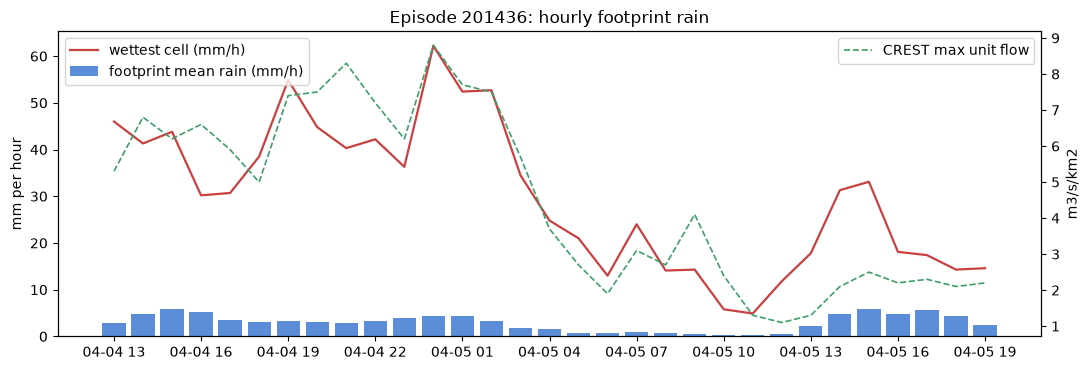

In [8]:
h = hourly[hourly.episode_id == ep_id].reset_index(drop=True)
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.bar(range(len(h)), h.rain_mean_mm, color="#5b8dd9", label="footprint mean rain (mm/h)")
ax.plot(range(len(h)), h.rain_max_mm, color="#c94040", lw=1.6, label="wettest cell (mm/h)")
step = max(1, len(h) // 8)
ax.set_xticks(range(0, len(h), step)); ax.set_xticklabels(h.hour_utc.iloc[::step].str.slice(5))
ax.set_ylabel("mm per hour"); ax.set_title(f"Episode {ep_id}: hourly footprint rain")
ax2 = ax.twinx(); ax2.plot(range(len(h)), h.crest_max, color="#3f9e6a", lw=1.2, ls="--", label="CREST max unit flow")
ax2.set_ylabel("m3/s/km2"); ax.legend(loc="upper left"); ax2.legend(loc="upper right"); plt.tight_layout(); plt.show()

## 4. Filtering cookbook

Every filter is one pandas expression on `episodes`. Two helpers first:

- `show(name, df)` prints a count with a label
- `water_year(s)` turns a UTC start time into the water year (October to September)

In [9]:
def show(name, df):
    print(f"{name:70s} {len(df):>6,}")

def water_year(s):
    t = pd.to_datetime(s, format="%Y-%m-%d %H")
    return t.dt.year + (t.dt.month >= 10).astype(int)

episodes["water_year"] = water_year(episodes.begin_utc)
episodes["month"] = pd.to_datetime(episodes.begin_utc, format="%Y-%m-%d %H").dt.month

show("all episodes", episodes)
show("water year 2025", episodes[episodes.water_year == 2025])
show("summer months (June to August)", episodes[episodes.month.between(6, 8)])
show("Texas or Oklahoma", episodes[episodes.states.str.contains("TX|OK")])
show("footprint inside a bounding box (Mid Atlantic)", episodes[(episodes.min_lat >= 36) & (episodes.max_lat <= 42) & (episodes.min_lon >= -80) & (episodes.max_lon <= -73)])
show("at least one fatality", episodes[episodes.fatalities >= 1])
show("damage at least 1 million dollars", episodes[episodes.damage_usd >= 1e6])
show("peak 1 h accumulation at least 50 mm somewhere", episodes[episodes.max1h_peak_mm >= 50])
show("a quarter of the footprint saw a 10 year or rarer 6 h rainfall", episodes[episodes.ari6h_cov_ge10yr >= 0.25])
show("CREST peak unit streamflow between 2 and 10", episodes[episodes.crest_peak_m3s_km2.between(2, 10)])
show("rain reached the guidance somewhere (max window)", episodes[episodes.ffgmax_peak_ratio >= 1])
show("at least one RUNOFF USGS gage in the footprint", episodes[episodes.n_gages >= 1])

all episodes                                                            5,418
water year 2025                                                         1,218
summer months (June to August)                                          3,415
Texas or Oklahoma                                                         626
footprint inside a bounding box (Mid Atlantic)                            604
at least one fatality                                                     150
damage at least 1 million dollars                                         208
peak 1 h accumulation at least 50 mm somewhere                          3,485
a quarter of the footprint saw a 10 year or rarer 6 h rainfall             30
CREST peak unit streamflow between 2 and 10                             2,877
rain reached the guidance somewhere (max window)                        5,009
at least one RUNOFF USGS gage in the footprint                          5,239


Some filters live at the watershed level. Filter `episode_huc8`, take the episode ids, then select
those episodes.

- HUC2 region: the first two characters of `huc8` (12 = Texas Gulf)
- radar coverage: watersheds with a mean under 50 percent

In [10]:
in_texas_gulf = episode_huc8[episode_huc8.huc8.str.startswith("12")].episode_id.unique()
show("episodes touching the Texas Gulf region (HUC2 = 12)", episodes[episodes.episode_id.isin(in_texas_gulf)])

poor = episode_huc8[episode_huc8.radar_coverage_mean < 50].episode_id.unique()
show("episodes with at least one poorly covered watershed (mean coverage < 50 %)", episodes[episodes.episode_id.isin(poor)])

flooded_poor = episode_huc8[(episode_huc8.radar_coverage_mean < 50) & (episode_huc8.flooded == 1)]
show("watershed-episodes reported flooded under poor radar coverage", flooded_poor)

episodes touching the Texas Gulf region (HUC2 = 12)                       504
episodes with at least one poorly covered watershed (mean coverage < 50 %)  2,368
watershed-episodes reported flooded under poor radar coverage           2,179


Combine conditions with `query`, then sort. This is how you build a shortlist of episodes for an experiment.

In [11]:
picked = episodes.query("n_events >= 10 and max6h_peak_mm >= 100 and ari6h_cov_ge10yr >= 0.10 and n_gages >= 1") \
                 .sort_values("ari6h_cov_ge10yr", ascending=False)
picked[["episode_id", "begin_utc", "states", "n_events", "n_lsr", "fatalities", "max6h_peak_mm",
        "ari6h_cov_ge10yr", "crest_peak_m3s_km2", "ffgmax_peak_ratio", "n_gages"]].head(10)

,episode_id,begin_utc,states,n_events,n_lsr,fatalities,max6h_peak_mm,ari6h_cov_ge10yr,crest_peak_m3s_km2,ffgmax_peak_ratio,n_gages
1072,163518,2021-09-01 22,NJ,52,39,13,225.0,0.512,50.3,16.65,103
4223,196957,2024-11-07 00,SC,18,20,0,259.9,0.484,16.6,29.45,25
3080,184690,2023-08-30 15,GA,18,19,0,161.3,0.425,12.1,2.40,1
1075,163260,2021-09-02 02,CT,15,12,0,183.0,0.387,62.0,22.65,82
3961,195693,2024-08-06 00,SC,43,43,0,188.1,0.381,26.7,34.80,5
1070,162538,2021-09-01 21,NJ,17,101,16,225.0,0.304,49.1,16.65,163
3035,182508,2023-08-20 01,CA,26,28,0,114.9,0.292,14.5,2.10,14
1071,163555,2021-09-01 21,NY,75,59,18,217.5,0.285,62.0,12.85,129
4193,195583,2024-09-27 19,OH,13,15,0,135.2,0.216,20.4,6.85,13
3038,185314,2023-08-20 15,CA,32,62,0,180.4,0.211,33.7,4.20,94


## 5. Summaries

Group, count, rank.

- by water year: `groupby` with named aggregations
- by state: `states` is a comma separated list, so split it and `explode` before counting
- by month: a bar chart of the episode start month

In [12]:
by_wy = episodes.groupby("water_year").agg(episodes=("episode_id", "size"), events=("n_events", "sum"),
                                           lsrs=("n_lsr", "sum"), fatalities=("fatalities", "sum"),
                                           damage_musd=("damage_usd", lambda s: round(s.sum() / 1e6)))
by_wy

,episodes,events,lsrs,fatalities,damage_musd
water_year,,,,,
2021,1160,4606,5632,136,2398
2022,1035,3222,4079,75,1139
2023,998,3395,3900,37,1484
2024,1007,4386,5160,110,2663
2025,1218,5273,6136,206,1828


In [13]:
by_state = (episodes.assign(state=episodes.states.str.split(",")).explode("state")
            .groupby("state").agg(episodes=("episode_id", "size"), fatalities=("fatalities", "sum"),
                                  damage_musd=("damage_usd", lambda s: round(s.sum() / 1e6)))
            .sort_values("episodes", ascending=False))
by_state.head(12)

,episodes,fatalities,damage_musd
state,,,
TX,510,159,1325
AZ,334,22,126
VA,245,5,230
NC,224,88,2193
LA,206,6,635
NM,200,19,538
PA,189,13,384
KY,181,53,20
IL,176,2,1093


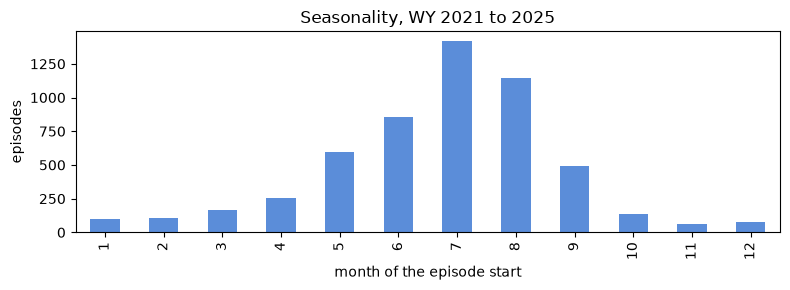

In [14]:
fig, ax = plt.subplots(figsize=(8, 3))
episodes.month.value_counts().sort_index().plot.bar(ax=ax, color="#5b8dd9")
ax.set_xlabel("month of the episode start"); ax.set_ylabel("episodes"); ax.set_title("Seasonality, WY 2021 to 2025")
plt.tight_layout(); plt.show()

The deadliest episodes, with the first line of their narrative.

In [15]:
top = episodes.sort_values(["fatalities", "damage_usd"], ascending=False).head(8).copy()
top["narrative_start"] = top.episode_narrative.fillna("").str.slice(0, 110)
top[["episode_id", "begin_utc", "states", "n_events", "fatalities", "damage_usd", "max6h_peak_mm", "narrative_start"]]

,episode_id,begin_utc,states,n_events,fatalities,damage_usd,max6h_peak_mm,narrative_start
4837,204934,2025-07-04 08,TX,23,117,205000000,272.9,Tropical Storm Barry moved into and dissipated over eastern Mexico. Moist air from the...
4175,196694,2024-09-25 23,NC,37,64,1558259500,404.8,Tropical Cyclone Helene began organizing over the western Caribbean on the 23rd and 24...
1739,172563,2022-07-28 01,KY,22,40,35000,186.9,"Between July 25th and July 30th, 2022, several complexes of training thunderstorms dev..."
965,162118,2021-08-21 10,TN,25,20,101034600,368.6,"The deadliest flash flood to ever affect Middle Tennessee, and one of the worst natura..."
1071,163555,2021-09-01 21,NY,75,18,470920000,217.5,Extremely heavy rainfall associated with the remnants of Hurricane Ida overspread sout...
1070,162538,2021-09-01 21,NJ,17,16,233000000,225.0,Post Tropical Cyclone Ida brought heavy rain to New Jersey on September 1. Rainfall to...
4172,195887,2024-09-25 18,TN,22,14,117800000,258.4,Tropical Storm Helene caps off a several day heavy rainfall event in association with ...
4640,204035,2025-06-12 02,TX,22,13,23100000,188.9,A mid-level shortwave trough moved over Texas and combined with an abnormally moist ai...


## 6. Maps without a GIS library

The repository ships simplified HUC8 polygons for the website (`assets/data/huc8.js`). When the
notebook runs inside the repository they draw the maps; otherwise the maps fall back to watershed
centroids.

- `huc8_map(values, title)` colours every watershed by a Series indexed by `huc8`
- it is used three times: reported flood frequency, radar coverage, and later the episodes themselves

2139 HUC8 polygons loaded


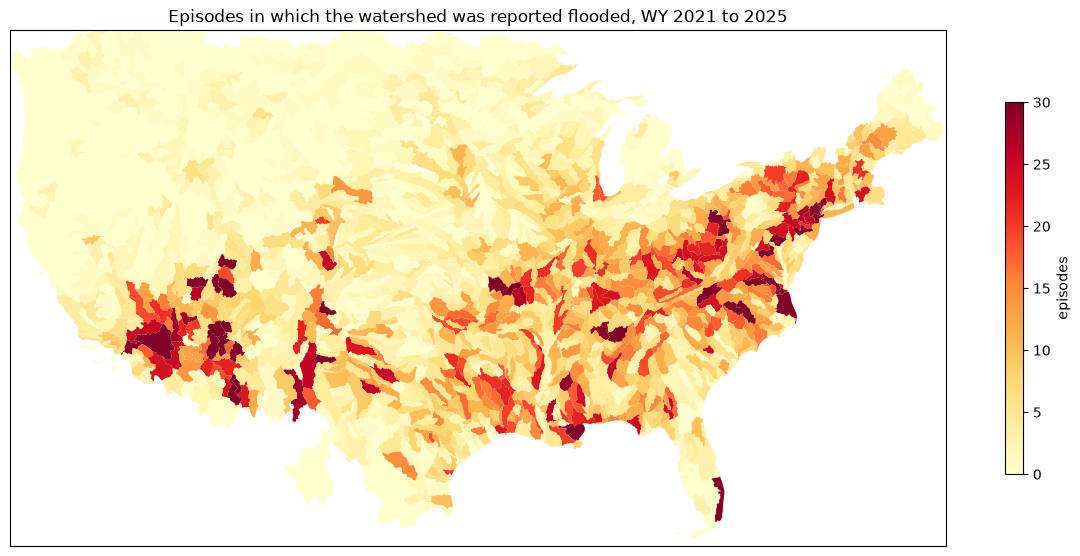

In [16]:
from matplotlib.collections import PolyCollection
from matplotlib.colors import Normalize

HUC_JS = ROOT / "assets" / "data" / "huc8.js"
POLYS = {}
if HUC_JS.exists():
    txt = HUC_JS.read_text(encoding="utf-8")
    gj = json.loads(txt[txt.index("{"):].rstrip().rstrip(";"))
    for f in gj["features"]:
        g = f["geometry"]
        parts = [g["coordinates"]] if g["type"] == "Polygon" else g["coordinates"]
        POLYS[f["properties"]["h"]] = [np.array(part[0]) for part in parts]   # outer ring of each part
    print(f"{len(POLYS)} HUC8 polygons loaded")
else:
    print("polygons not found; maps use centroids")

def huc8_map(values, title, cmap="YlOrRd", vmin=None, vmax=None, label="", ax=None):
    v = values.dropna()
    norm = Normalize(vmin if vmin is not None else v.min(), vmax if vmax is not None else v.max())
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6.5))
    if POLYS:
        verts, cols = [], []
        for code_, val in v.items():
            for ring in POLYS.get(code_, []):
                verts.append(ring); cols.append(val)
        pc = PolyCollection(verts, array=np.array(cols), cmap=cmap, norm=norm, edgecolor="none")
        ax.add_collection(pc); plt.colorbar(pc, ax=ax, shrink=0.6, label=label)
    else:
        c = huc8.set_index("huc8").loc[v.index]
        sc = ax.scatter((c.min_lon + c.max_lon) / 2, (c.min_lat + c.max_lat) / 2, c=v.values, s=14, cmap=cmap, norm=norm)
        plt.colorbar(sc, ax=ax, shrink=0.6, label=label)
    ax.set_xlim(-125, -66); ax.set_ylim(24, 50); ax.set_aspect(1.25); ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
    return ax

huc8_map(huc8.set_index("huc8").n_flooded_episodes, "Episodes in which the watershed was reported flooded, WY 2021 to 2025",
         vmax=30, label="episodes"); plt.tight_layout(); plt.show()

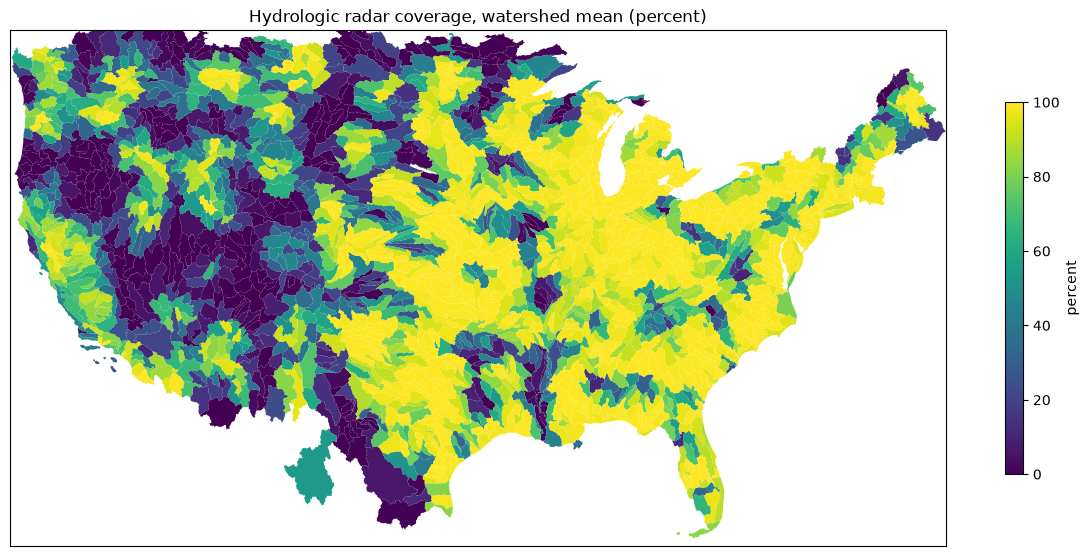

In [17]:
huc8_map(huc8.set_index("huc8").radar_coverage_mean, "Hydrologic radar coverage, watershed mean (percent)", cmap="viridis",
         vmin=0, vmax=100, label="percent"); plt.tight_layout(); plt.show()

Episodes as points at the centre of their report bounding box. Colour is the peak 6 h rain, size the number of reports.

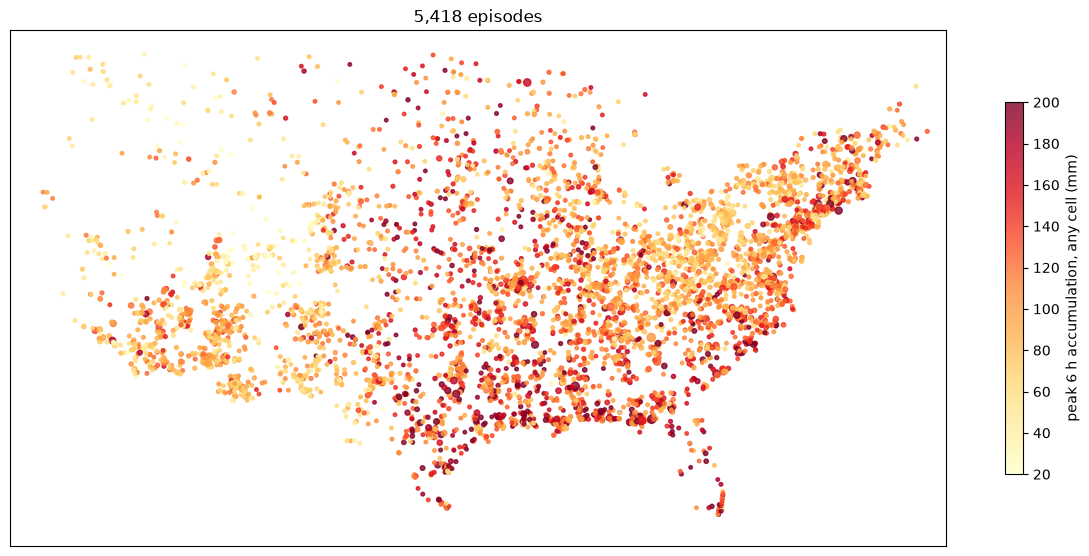

In [18]:
fig, ax = plt.subplots(figsize=(12, 6.5))
sc = ax.scatter((episodes.min_lon + episodes.max_lon) / 2, (episodes.min_lat + episodes.max_lat) / 2,
                c=episodes.max6h_peak_mm, s=6 + episodes.n_events.clip(upper=60) / 2, cmap="YlOrRd", vmin=20, vmax=200, alpha=.8)
plt.colorbar(sc, ax=ax, shrink=0.6, label="peak 6 h accumulation, any cell (mm)")
ax.set_xlim(-125, -66); ax.set_ylim(24, 50); ax.set_aspect(1.25); ax.set_xticks([]); ax.set_yticks([])
ax.set_title("5,418 episodes"); plt.tight_layout(); plt.show()

## 7. The narratives

Both report tables carry the text the forecaster wrote. Plain string matching turns text into
attributes.

- `str.contains(pattern, case=False)` flags a report that mentions a keyword
- summing the flags per episode gives a new episode attribute, here the number of rescue mentions

In [19]:
kw = {"rescue": "rescue", "vehicle": "vehicle|car |cars |truck", "road closed": "closed|impassable",
      "homes": "home|house|residen", "swift water": "swift water|swiftwater"}
rows = []
for k, pat in kw.items():
    rows.append({"keyword": k,
                 "Storm Events reports": int(events.narrative.fillna("").str.contains(pat, case=False).sum()),
                 "Local Storm Reports": int(lsrs.narrative.fillna("").str.contains(pat, case=False).sum())})
pd.DataFrame(rows).set_index("keyword")

,Storm Events reports,Local Storm Reports
keyword,,
rescue,1603,1622
vehicle,2894,3120
road closed,5467,6093
homes,1711,1484
swift water,224,219


In [20]:
rescues = (events.assign(r=events.narrative.fillna("").str.contains("rescue", case=False)).groupby("episode_id").r.sum()
           .add(lsrs.assign(r=lsrs.narrative.fillna("").str.contains("rescue", case=False)).groupby("episode_id").r.sum(), fill_value=0))
episodes["n_rescue_mentions"] = episodes.episode_id.map(rescues).fillna(0).astype(int)
episodes.sort_values("n_rescue_mentions", ascending=False)[["episode_id", "begin_utc", "states", "n_events", "n_lsr", "fatalities", "n_rescue_mentions"]].head(6)

,episode_id,begin_utc,states,n_events,n_lsr,fatalities,n_rescue_mentions
939,160226,2021-08-19 03,PA,33,48,0,42
4059,196197,2024-08-19 02,NY,40,45,0,27
4941,203071,2025-07-14 18,PA,33,32,0,23
4324,201140,2025-04-03 17,KY,51,60,3,23
973,160873,2021-08-22 05,NJ,31,49,0,23
5403,207295,2025-09-25 21,AZ,42,38,4,22


Who reports LSRs, and what the text looks like for one keyword.

In [21]:
print(lsrs.source.fillna("unknown").str.upper().value_counts().head(8).to_string())
print()
for _, r in lsrs[lsrs.narrative.fillna("").str.contains("swift water", case=False)].head(4).iterrows():
    print(f"{r.valid_utc}  {r.county}, {r.wfo}: {r.narrative}")

source
PUBLIC              5103
EMERGENCY MNGR      4446
911 CALL CENTER     3413
LAW ENFORCEMENT     2766
DEPT OF HIGHWAYS    2504
BROADCAST MEDIA     1412
TRAINED SPOTTER     1201
FIRE DEPT/RESCUE    1060

2021-03-18 01:00  MORGAN, HUN: RESCUE SQUAD RESPONDING TO A SWIFT WATER RESCUE ON WILHITE ROAD IN LACON.
2021-03-01 04:30  ROBERTSON, OHX: SEVERAL SWIFT WATER RESCUES IN PROGRESS ACROSS ROBERTSON COUNTY INCLUDING ONE NEAR PLEASANT VIEW
2021-03-19 00:03  KANAWHA, RLX: BROUNLAND ROAD CLOSED DUE TO NEARBY CREEK OVERFLOWING OUT OF ITS BANKS ONTO THE ROADWAY. A SWIFT WATER RESCUE WAS CONDUCTED.
2021-04-29 11:00  JOHNSON, LZK: HIGHWAY 64 CLOSED DUE TO HIGH WATER OVER ROAD. TWO SWIFT WATER RESCUES OCCURRED, ONE ON HIGHWAY 359 NEAR PINEY CREEK, AND THE OTHER ON HIGHWAY 164 NEAR HORSEHEAD CREEK.


## 8. Timing inside an episode

The summary columns say how much it rained. `hourly` and the report times say when.

- find the wettest footprint hour of each episode in `hourly`
- find the first report time from `events` and `lsrs`
- the difference is the lag between the peak rain and the first report

median lag from the wettest footprint hour to the first report: -0.5 h (negative = report before the peak hour); 86 % within -3 to +6 h


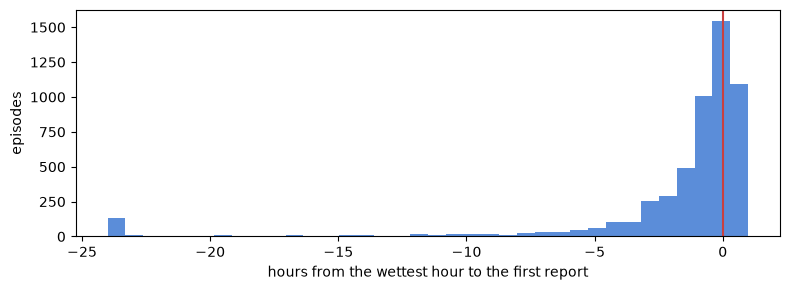

In [22]:
peak_hour = hourly.loc[hourly.groupby("episode_id").rain_max_mm.idxmax(), ["episode_id", "hour_utc"]].set_index("episode_id").hour_utc
first_report = pd.concat([events.groupby("episode_id").begin_utc.min().str.slice(0, 16),
                          lsrs.groupby("episode_id").valid_utc.min()]).groupby(level=0).min()
lag = (pd.to_datetime(first_report, format="%Y-%m-%d %H:%M") -
       pd.to_datetime(peak_hour.reindex(first_report.index), format="%Y-%m-%d %H")).dt.total_seconds() / 3600
lag = lag.dropna()
print(f"median lag from the wettest footprint hour to the first report: {lag.median():.1f} h "
      f"(negative = report before the peak hour); {100 * lag.between(-3, 6).mean():.0f} % within -3 to +6 h")
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(lag.clip(-24, 48), bins=36, color="#5b8dd9"); ax.axvline(0, color="#c94040")
ax.set_xlabel("hours from the wettest hour to the first report"); ax.set_ylabel("episodes"); plt.tight_layout(); plt.show()

`hourly` also carries the FLASH products, so an episode can be replayed hour by hour, the way a forecaster saw it.

In [23]:
hourly[hourly.episode_id == ep_id][["hour_utc", "rain_mean_mm", "rain_max_mm", "ari1h_max_yr", "crest_max", "ffg1h_max", "ffgmax_max"]].head(12)

,hour_utc,rain_mean_mm,rain_max_mm,ari1h_max_yr,crest_max,ffg1h_max,ffgmax_max
40249,2025-04-04 13,2.9,46.0,5.6,5.3,1.25,1.25
40250,2025-04-04 14,4.8,41.3,2.9,6.8,0.85,1.30
40251,2025-04-04 15,5.8,43.8,6.8,6.2,1.00,2.25
40252,2025-04-04 16,5.2,30.2,2.4,6.6,0.95,2.25
40253,2025-04-04 17,3.5,30.7,1.2,5.9,0.65,2.25
40254,2025-04-04 18,3.0,38.5,2.5,5.0,0.95,1.55
40255,2025-04-04 19,3.4,54.9,10.0,7.4,1.15,1.65
40256,2025-04-04 20,3.0,44.8,7.3,7.5,1.25,1.45
40257,2025-04-04 21,2.9,40.3,4.8,8.3,2.00,9.55
40258,2025-04-04 22,3.4,42.2,5.8,7.2,2.65,9.35


## 9. The modeling table

For a flash flood guidance style detector the unit is one watershed in one episode. `episode_huc8`
is already that table.

- features: rainfall, return period coverage, FLASH, guidance, gages, radar coverage
- label: `flooded`, 1 when any report fell inside the watershed during the episode
- split by time: train on water years 2021 to 2024, test on 2025
- scores: POD (hits over all floods), FAR (false alarms over all alarms), CSI (hits over everything but the correct quiet rows)

First, two operational style rules with no learning, to know the bar.

In [24]:
features = ["rain_ep_mean_mm", "rain_ep_max_mm", "rain_pre5h_mean_mm",
            "max1h_peak_mm", "max1h_mean_of_peaks_mm", "max3h_peak_mm", "max6h_peak_mm", "max6h_mean_of_peaks_mm",
            "ari1h_peak_yr", "ari3h_peak_yr", "ari6h_peak_yr",
            "ari1h_cov_ge2yr", "ari1h_cov_ge10yr", "ari6h_cov_ge2yr", "ari6h_cov_ge10yr", "ari6h_cov_ge50yr",
            "crest_peak_m3s_km2", "sac_peak_m3s_km2", "hp_peak_m3s_km2",
            "ffg1h_peak_ratio", "ffg3h_peak_ratio", "ffg6h_peak_ratio", "ffgmax_peak_ratio",
            "huc8_area_km2", "inside_counties_frac", "n_gages", "radar_coverage_mean", "radar_coverage_frac_ge50"]
label = "flooded"

table = episode_huc8.merge(episodes[["episode_id", "water_year"]], on="episode_id")
train = table[table.water_year <= 2024]
test = table[table.water_year == 2025]
print(f"rows {len(table):,} | positives {table[label].mean():.1%} | train {len(train):,} | test {len(test):,}")

def scores(y, yhat):
    y, yhat = np.asarray(y), np.asarray(yhat)
    hits = int(((y == 1) & (yhat == 1)).sum()); miss = int(((y == 1) & (yhat == 0)).sum()); fa = int(((y == 0) & (yhat == 1)).sum())
    return {"POD": round(hits / max(hits + miss, 1), 3), "FAR": round(fa / max(hits + fa, 1), 3), "CSI": round(hits / max(hits + miss + fa, 1), 3)}

baselines = {
    "rain reached the guidance somewhere (ffgmax peak >= 1)": (test.ffgmax_peak_ratio >= 1).astype(int),
    "any cell at a 2 year 6 h rainfall": (test.ari6h_cov_ge2yr > 0).astype(int),
    "CREST peak unit streamflow >= 2": (test.crest_peak_m3s_km2 >= 2).astype(int),
    "a fifth of the watershed at a 5 year 6 h rainfall": (test.ari6h_cov_ge5yr >= 0.2).astype(int),
}
pd.DataFrame({k: scores(test[label], v) for k, v in baselines.items()}).T

rows 35,697 | positives 32.1% | train 27,969 | test 7,728


,POD,FAR,CSI
rain reached the guidance somewhere (ffgmax peak >= 1),0.874,0.536,0.434
any cell at a 2 year 6 h rainfall,0.860,0.552,0.417
CREST peak unit streamflow >= 2,0.883,0.504,0.465
a fifth of the watershed at a 5 year 6 h rainfall,0.074,0.259,0.072


Now a first learned model. Gradient boosting handles missing values and mixed scales without any
preparation, which is why it is the right first try.

- `HistGradientBoostingClassifier` from scikit-learn (`pip install scikit-learn` if the import fails)
- the threshold on the predicted probability trades POD against FAR
- permutation importance says which columns the model leans on: shuffle one column, see how much the skill drops

                                    POD    FAR    CSI
gradient boosting, threshold 0.3  0.852  0.338  0.594
gradient boosting, threshold 0.4  0.785  0.291  0.594
gradient boosting, threshold 0.5  0.720  0.244  0.584


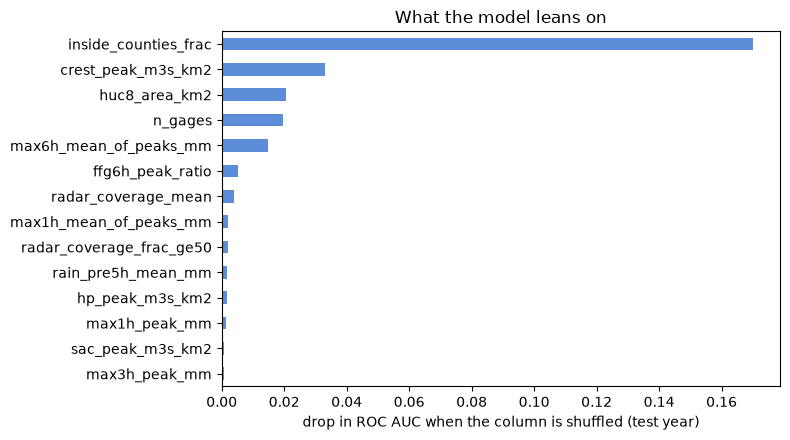

In [25]:
try:
    from sklearn.ensemble import HistGradientBoostingClassifier
    from sklearn.inspection import permutation_importance
    clf = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, max_leaf_nodes=31, random_state=0)
    clf.fit(train[features], train[label])
    p = clf.predict_proba(test[features])[:, 1]
    print(pd.DataFrame({f"gradient boosting, threshold {t}": scores(test[label], (p >= t).astype(int)) for t in (0.3, 0.4, 0.5)}).T)
    imp = permutation_importance(clf, test[features], test[label], n_repeats=5, random_state=0, scoring="roc_auc")
    imp = pd.Series(imp.importances_mean, index=features).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(8, 4.5)); imp.head(14)[::-1].plot.barh(ax=ax, color="#5b8dd9")
    ax.set_xlabel("drop in ROC AUC when the column is shuffled (test year)"); ax.set_title("What the model leans on"); plt.tight_layout(); plt.show()
except ImportError:
    print("scikit-learn is not installed (pip install scikit-learn); the baselines above need nothing extra")

## 10. The radar layer

`data/radar_cov.tif` is a hydrologic radar coverage layer on the 0.01 degree MRMS grid.

- at every pixel, the value is the percent of the drainage area upstream of that pixel that weather
  radar covers (0 to 100)
- so the value at a gage is the coverage of the whole basin above the gage
- and the value at a flash flood report is the coverage of the basin draining to that place
- it is not a plain "is this pixel under a radar" map; it already integrates over the basin

The dataset carries it three ways:

- sampled at each gage: `radar_coverage_at_gage` in `gages`
- sampled at each report: `radar_coverage_at_report` in `events` and `lsrs`, and averaged per
  watershed and episode as `radar_coverage_at_reports_mean` in `episode_huc8`
- summarized over all pixels of a watershed: `radar_coverage_mean/min/max/frac_ge50/frac_ge100` in
  `huc8` and `episode_huc8`

Below, the layer itself around one gage. Reading a GeoTIFF needs `rasterio`
(`pip install rasterio`); the cell skips itself when it is missing.

In [26]:
# choose a gage: a basin polygon available, mid range coverage, a real basin size, the most RUNOFF events
cand = gages[(gages.basin_polygon == 1) & gages.radar_coverage_at_gage.between(30, 70) & (gages.drainage_area_km2 >= 100)]
gage = cand.sort_values("n_runoff_events", ascending=False).iloc[0]
print(f"USGS {gage.site_no} {gage.station_name}: {gage.drainage_area_km2:.0f} km2, HUC8 {gage.huc8}, "
      f"hydrologic radar coverage at the gage {gage.radar_coverage_at_gage:.0f} %")
gage_hu = huc8.set_index("huc8").loc[gage.huc8]
print(f"its HUC8 ({gage_hu['name']}): watershed mean {gage_hu.radar_coverage_mean:.0f} %, min {gage_hu.radar_coverage_min:.0f} %, "
      f"max {gage_hu.radar_coverage_max:.0f} %, share of the area above 50 %: {100 * gage_hu.radar_coverage_frac_ge50:.0f} %")

USGS 06738000 Big Thompson River At Mouth Of Canyon Nr Drake, Co: 791 km2, HUC8 10190006, hydrologic radar coverage at the gage 38 %
its HUC8 (Big Thompson): watershed mean 66 %, min 0 %, max 100 %, share of the area above 50 %: 68 %


What the next cell does:

- opens the GeoTIFF and reads only the window around the basin (fast, no full grid in memory)
- draws the coverage pixels, the basin polygon of the gage (`assets/data/basin/<site_no>.json`),
  the HUC8 outline and the gage itself
- prints the value at the gage next to the mean of the pixels inside the basin, so the two ways of
  reading the layer sit side by side

value at the gage (coverage of the whole basin above it): 38 %
mean of the pixels inside the basin polygon: 39 %  (each pixel is the coverage of its own upstream area)


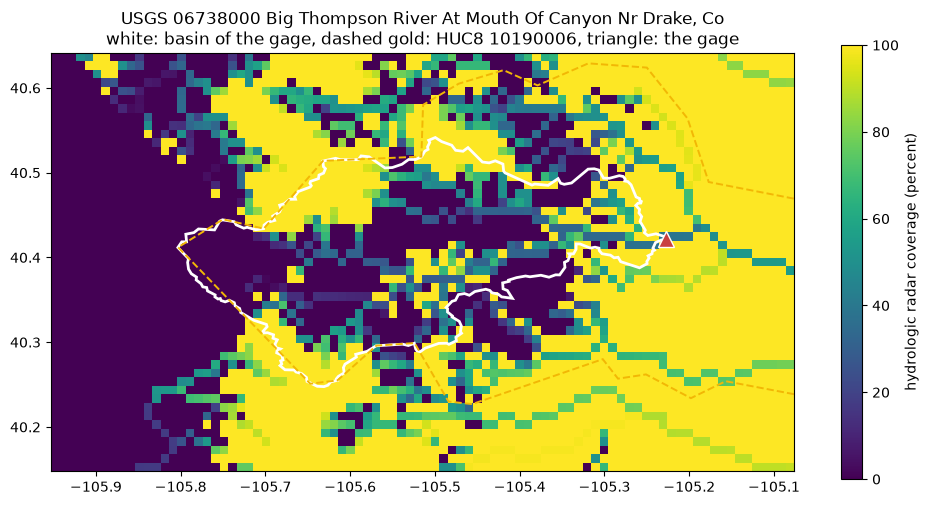

In [27]:
try:
    import rasterio
    from rasterio.windows import from_bounds
    from rasterio.features import geometry_mask
    from matplotlib.patches import Polygon as MplPolygon

    basin_path = ROOT / "assets" / "data" / "basin" / f"{gage.site_no}.json"
    basin = json.loads(basin_path.read_text()) if basin_path.exists() else None
    if basin:
        rings = [basin["geometry"]["coordinates"]] if basin["geometry"]["type"] == "Polygon" else basin["geometry"]["coordinates"]
        xs = np.concatenate([np.array(r[0])[:, 0] for r in rings]); ys = np.concatenate([np.array(r[0])[:, 1] for r in rings])
        west, south, east, north = xs.min() - .15, ys.min() - .1, xs.max() + .15, ys.max() + .1
    else:
        west, south, east, north = gage.lon - .5, gage.lat - .4, gage.lon + .5, gage.lat + .4

    with rasterio.open(DATA / "radar_cov.tif") as src:
        win = from_bounds(west, south, east, north, src.transform)
        cov = src.read(1, window=win).astype("float64")
        cov[cov == src.nodata] = np.nan
        wtr = src.window_transform(win)
        at_gage = float(next(src.sample([(gage.lon, gage.lat)]))[0])

    fig, ax = plt.subplots(figsize=(10, 6.5))
    im = ax.imshow(cov, extent=(west, east, south, north), cmap="viridis", vmin=0, vmax=100, origin="upper")
    plt.colorbar(im, ax=ax, shrink=0.7, label="hydrologic radar coverage (percent)")
    if basin:
        for r in rings:
            ax.add_patch(MplPolygon(np.array(r[0]), closed=True, fill=False, edgecolor="white", lw=2))
        mask = geometry_mask([basin["geometry"]], out_shape=cov.shape, transform=wtr, invert=True)
        inside = cov[mask & np.isfinite(cov)]
        print(f"value at the gage (coverage of the whole basin above it): {at_gage:.0f} %")
        print(f"mean of the pixels inside the basin polygon: {inside.mean():.0f} %  (each pixel is the coverage of its own upstream area)")
    for ring in POLYS.get(gage.huc8, []):
        ax.add_patch(MplPolygon(ring, closed=True, fill=False, edgecolor="#f2b705", lw=1.4, ls="--"))
    ax.plot(gage.lon, gage.lat, marker="^", color="#c94040", markersize=12, markeredgecolor="white")
    ax.set_xlim(west, east); ax.set_ylim(south, north)
    ax.set_title(f"USGS {gage.site_no} {gage.station_name}\nwhite: basin of the gage, dashed gold: HUC8 {gage.huc8}, triangle: the gage")
    plt.tight_layout(); plt.show()
except ImportError:
    print("rasterio is not installed (pip install rasterio); the sampled columns in the tables do not need it")

Why the two numbers differ: every pixel inside the basin is the coverage of its own upstream area.
Headwater pixels drain small areas; the pixel at the outlet drains all of them. The value at the gage
is the number that describes the basin as a whole. The watershed statistics (mean, min, max) are the
summary you use when there is no single outlet to point at, as for a HUC8.

Now the question behind the layer: do poorly covered watersheds get reported flooded less often for
the same rainfall?

- keep rows where the peak 1 h rain reached at least 40 mm, so rainfall is comparable
- group by the watershed mean coverage
- compare the share reported flooded, and look at the gage density of the same bands

In [28]:
band = pd.cut(episode_huc8.radar_coverage_mean, [-0.1, 10, 50, 90, 100.1], labels=["0-10", "10-50", "50-90", "90-100"])
strong = episode_huc8.max1h_peak_mm >= 40
out = (episode_huc8.assign(coverage_band=band)[strong]
       .groupby("coverage_band", observed=True).agg(watershed_episodes=("flooded", "size"), reported_flooded=("flooded", "mean"),
                                                    mean_peak_1h_mm=("max1h_peak_mm", "mean"), gages_per_watershed=("n_gages", "mean")))
out.reported_flooded = out.reported_flooded.round(3); out[["mean_peak_1h_mm", "gages_per_watershed"]] = out[["mean_peak_1h_mm", "gages_per_watershed"]].round(1)
print("watershed-episodes with a peak 1 h accumulation of at least 40 mm, by radar coverage band")
out

watershed-episodes with a peak 1 h accumulation of at least 40 mm, by radar coverage band


,watershed_episodes,reported_flooded,mean_peak_1h_mm,gages_per_watershed
coverage_band,,,,
0-10,1024,0.292,54.8,0.8
10-50,2279,0.380,56.9,2.1
50-90,3810,0.493,57.3,3.4
90-100,8581,0.541,57.9,4.6


Read it with care. Two things lower the reported rate where coverage is poor:

- fewer people and roads, so fewer reports; the gage density falls the same way, and gages follow people too
- radar underestimates rain where it does not see, so the measured rainfall itself is lower there

The coverage columns let a model learn this mismatch. They do not say which of the two it is. For a
radar siting argument, this table is the starting point, not the conclusion.

## 11. Labels and negatives

`flooded` is one label. The tables allow others, and the split matters as much as the model.

- events only: `n_events > 0`; LSRs only: `n_lsr > 0`. LSRs are more numerous; Storm Events are curated
- severity: `fatalities > 0` or `damage_usd >= 100000` inside the watershed
- a watershed prior (how often it was reported before) is a strong feature and an easy leak; compute it
  on the training years only
- the negatives here are watersheds inside a storm footprint with no report. Watersheds with no storm are
  not in the table. A model for "will it flash flood" from a quiet start needs them added, which is the
  next version of the dataset

In [29]:
prior = train.groupby("huc8").flooded.mean().rename("huc8_prior_train")
train2 = train.merge(prior, on="huc8", how="left")
test2 = test.merge(prior, on="huc8", how="left").fillna({"huc8_prior_train": train.flooded.mean()})
alt = {"events only": (episode_huc8.n_events > 0).mean(), "LSRs only": (episode_huc8.n_lsr > 0).mean(),
       "any report (flooded)": episode_huc8.flooded.mean(),
       "severe (fatality or damage >= 100k)": ((episode_huc8.fatalities > 0) | (episode_huc8.damage_usd >= 1e5)).mean()}
print("positive share under alternative labels:"); print(pd.Series(alt).round(3).to_string())
try:
    from sklearn.ensemble import HistGradientBoostingClassifier
    f2 = features + ["huc8_prior_train"]
    clf2 = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, max_leaf_nodes=31, random_state=0).fit(train2[f2], train2[label])
    print("\nwith the leak-free watershed prior, threshold 0.3:", scores(test2[label], (clf2.predict_proba(test2[f2])[:, 1] >= 0.3).astype(int)))
except ImportError:
    pass

positive share under alternative labels:
events only                            0.298
LSRs only                              0.284
any report (flooded)                   0.321
severe (fatality or damage >= 100k)    0.028



with the leak-free watershed prior, threshold 0.3: {'POD': 0.829, 'FAR': 0.332, 'CSI': 0.587}


## 12. Gages: the bridge to the gaged path

`episode_gages` lists every RUNOFF gage inside every footprint.

- join it with `gages` for names, drainage areas and the coverage at the gage
- join it with `episode_huc8` to know whether that watershed was reported flooded
- a gaged, flooded watershed is a candidate for the NextGen experiment path of RUNOFF
- the basin polygon of each gage is under `assets/data/basin/<site_no>.json` in the repository

In [30]:
gaged = (episode_gages.merge(gages.drop(columns=["huc8"]), on="site_no")
                      .merge(episode_huc8[["episode_id", "huc8", "flooded", "max1h_peak_mm", "ari6h_peak_yr"]], on=["episode_id", "huc8"]))
print(f"{len(gaged):,} gage-episode pairs, {gaged.site_no.nunique():,} distinct gages, "
      f"{gaged[gaged.flooded == 1].site_no.nunique():,} gages in a watershed reported flooded at least once")
candidates = (gaged[gaged.flooded == 1].groupby(["site_no", "station_name", "drainage_area_km2", "radar_coverage_at_gage"]).size()
              .rename("flooded_episodes").reset_index().sort_values("flooded_episodes", ascending=False))
candidates.head(8)

119,770 gage-episode pairs, 5,285 distinct gages, 4,612 gages in a watershed reported flooded at least once


,site_no,station_name,drainage_area_km2,radar_coverage_at_gage,flooded_episodes
983,02042500,"Chickahominy River Near Providence Forge, Va",646.9,100.0,59
978,02038000,"Falling Creek Near Chesterfield, Va",87.7,100.0,59
910,01653500,"Henson Creek At Oxon Hill, Md",44.8,100.0,58
911,01653600,"Piscataway Creek At Piscataway, Md",102.7,100.0,58
912,01654000,"Accotink Creek Near Annandale, Va",60.7,100.0,58
907,01651800,"Watts Branch At Washington, Dc",8.6,100.0,58
906,01651000,"Northwest Br Anacostia River Nr Hyattsville, Md",127.8,100.0,58
905,01650800,"Sligo Creek Near Takoma Park, Md",16.7,100.0,58


In [31]:
candidates.site_no.to_csv("gages_for_nextgen.csv", index=False)
print("written gages_for_nextgen.csv: paste these site numbers into the RUNOFF NextGen wizard, or into your own retrieval")

written gages_for_nextgen.csv: paste these site numbers into the RUNOFF NextGen wizard, or into your own retrieval


## 13. GIS export

Attach the watershed statistics of a filtered set to polygons and write GeoJSON for QGIS or ArcGIS.
With the repository polygons this needs only the `json` module.

In [32]:
if POLYS:
    sel = episode_huc8[episode_huc8.episode_id == ep_id]
    feats = []
    for _, r in sel.iterrows():
        rings = POLYS.get(r.huc8)
        if not rings:
            continue
        props = {}
        for k, v in r.items():
            if k == "gage_ids":
                continue
            props[k] = None if pd.isna(v) else (float(v) if isinstance(v, (np.floating, float)) else (int(v) if isinstance(v, (np.integer, int)) else str(v)))
        feats.append({"type": "Feature", "properties": props,
                      "geometry": {"type": "MultiPolygon", "coordinates": [[ring.tolist()] for ring in rings]}})
    Path(f"episode_{ep_id}_huc8.geojson").write_text(json.dumps({"type": "FeatureCollection", "features": feats}))
    print(f"episode_{ep_id}_huc8.geojson: {len(feats)} watersheds with all their statistics as properties")
else:
    print("polygons not available here; use the WBD HUC8 layer and join on huc8")

episode_201436_huc8.geojson: 23 watersheds with all their statistics as properties


## 14. Saving subsets, and notes on the numbers

Filter, then write. Parquet keeps the types; CSV opens in Excel (read it back with `dtype={"huc8": str}`).

In [33]:
ids = picked.episode_id.head(20)
out = Path("my_subset"); out.mkdir(exist_ok=True)
episodes[episodes.episode_id.isin(ids)].drop(columns=["water_year", "month", "n_rescue_mentions"]).to_csv(out / "episodes.csv", index=False)
episode_huc8[episode_huc8.episode_id.isin(ids)].to_parquet(out / "episode_huc8.parquet", index=False)
events[events.episode_id.isin(ids)].to_csv(out / "events.csv", index=False)
lsrs[lsrs.episode_id.isin(ids)].to_csv(out / "lsrs.csv", index=False)
print("written:", sorted(p.name for p in out.iterdir()))

written: ['episode_huc8.parquet', 'episodes.csv', 'events.csv', 'lsrs.csv']


Notes on the numbers:

- Rain: MRMS MultiSensor QPE 1 h Pass 2 (gauge corrected). Rolling windows end from the episode start
  hour to one hour after its end; the five hours before the start are read so the first 6 h window is
  complete.
- Return periods: FLASH QPE_ARI products (NOAA Atlas 14 based), sampled at the top of each hour;
  `_cov_geTyr` is the share of the unit area at or above T years at any hour of the episode.
- FLASH unit streamflow and QPE/FFG ratios are read at the top of each hour of the window only. The
  ratio is 1.0 when the rain reached the guidance. If the `_share_ge1` columns are empty in your copy,
  the FLASH pass predates the percent to ratio fix; a rerun fills them.
- Radar coverage is hydrologic: at each pixel, the percent of the upstream drainage area covered by
  weather radar. The QPE itself is less reliable where coverage is poor, so coverage is a feature and
  a caveat at the same time.
- Coordinates in `events` and `lsrs` are NWS report locations, not storm centers. The footprint and
  the MRMS columns describe the storm. Reports follow people and roads; treat the label accordingly.